In [1]:
%load_ext autoreload
%autoreload 1
%aimport 

Modules to reload:


Modules to skip:



In [2]:
import os
import random
from datasets import Dataset, DatasetDict, Audio, load_from_disk
from sklearn.model_selection import train_test_split
from transformers import WhisperProcessor
import torch
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

/home/jangkj/.conda/envs/tta_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# CONFIG
data_dir = "../TTA_data/FR"
test_size = 0.2  # 20% test split
random.seed(42)

In [4]:
# all_data = []
# for fname in os.listdir(data_dir):
#     if fname.endswith(".flac"):
#         base = os.path.splitext(fname)[0]
#         audio_path = os.path.join(data_dir, fname)
#         txt_path = os.path.join(data_dir, f"{base}.txt")

#         if os.path.exists(txt_path):
#             with open(txt_path, "r", encoding="utf-8") as f:
#                 transcript = f.read().strip()
#             all_data.append({
#                 "audio": audio_path,
#                 "transcription": transcript
#             })

# all_data[0]

In [5]:
# train_data, test_data = train_test_split(all_data, test_size=test_size)
# train_data[0]

In [6]:
# train_dataset = Dataset.from_list(train_data).cast_column("audio", Audio(decode=True))
# test_dataset = Dataset.from_list(test_data).cast_column("audio", Audio(decode=True))

In [7]:
# dataset = DatasetDict({
#     "train": train_dataset,
#     "test": test_dataset
# })

In [8]:
audio_paths = []
transcriptions = []

# Walk through all .flac files and find matching .txt files
for fname in os.listdir(data_dir):
    if fname.endswith(".wav"):
        base = os.path.splitext(fname)[0]
        audio_path = os.path.join(data_dir, fname)
        txt_path = os.path.join(data_dir, base + ".txt")
        
        if os.path.exists(txt_path):
            with open(txt_path, "r", encoding="utf-8") as f:
                transcription = f.read().strip()
            audio_paths.append(audio_path)
            transcriptions.append(transcription)

# Check the first entry
print({"audio": audio_paths[0], "transcription": transcriptions[0]})

{'audio': '../TTA_data/FR/0038ee83-88a6-4bee-b81b-c4cb2d078fc2.wav', 'transcription': "ici tout le monde vit dans detente côte à côte c'est très pénible tout cela est en train de détruire nos vies il n'y a rien à manger c'est trop cher la situation ici est très difficile estce qu'il y a des contaminations au coronavirus"}


In [9]:
processor = WhisperProcessor.from_pretrained(
    "openai/whisper-small", language="french", task="transcribe"
    )

sampling_rate = processor.feature_extractor.sampling_rate
print(f"Sampling Rate: {sampling_rate}")

Sampling Rate: 16000


In [10]:
train_paths, test_paths, train_texts, test_texts = train_test_split(
    audio_paths, transcriptions, test_size=0.2, random_state=42
)

train_ds = Dataset.from_dict({
    "audio": train_paths,
    "transcription": train_texts
}).cast_column("audio", Audio(decode=True, sampling_rate=sampling_rate))

test_ds = Dataset.from_dict({
    "audio": test_paths,
    "transcription": test_texts
}).cast_column("audio", Audio(decode=True, sampling_rate=sampling_rate))

dataset = DatasetDict({
    "train": train_ds,
    "test": test_ds
})

In [11]:
print(train_ds[0])
sample = dataset["train"][0] 
audio_data = sample["audio"]

print(audio_data["array"].shape)
waveform = torch.tensor(audio_data["array"])
print(waveform.shape)  # shape: (num_channels, num_samples)
print(waveform)         # waveform shape
print(audio_data["sampling_rate"])       # typically 16kHz or 44.1kHz
print(sample["transcription"])    

{'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7fe242acc750>, 'transcription': "plus tard on en est là où il y a encore des gens qui se font tuer quoi parce que tant que il y aura pas une sorte de un débat public sur ça et que les gens ne prennent pas conscient de ce phénomène là s'il y aura pas de changement une manifestation qui je le disais se"}
(238400,)
torch.Size([238400])
tensor([0., 0., 0.,  ..., 0., 0., 0.])
16000
plus tard on en est là où il y a encore des gens qui se font tuer quoi parce que tant que il y aura pas une sorte de un débat public sur ça et que les gens ne prennent pas conscient de ce phénomène là s'il y aura pas de changement une manifestation qui je le disais se


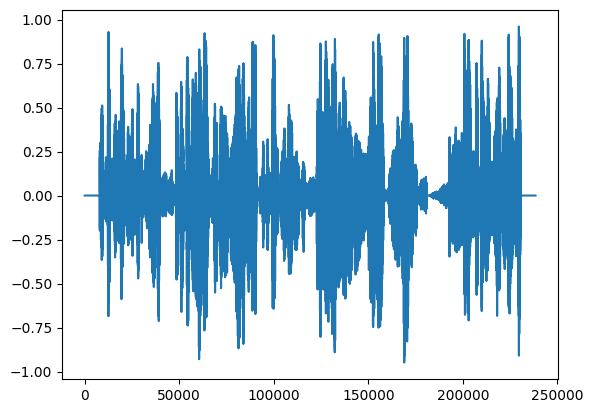

In [12]:
plt.plot(waveform.t().numpy())

In [13]:
dataset.save_to_disk("openSLR-FR")

Saving the dataset (0/2 shards):   0%|          | 0/1998 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 500/500 [00:00<00:00, 1195.82 examples/s]


In [14]:
entry = dataset["train"][10]
print(entry["audio"]["array"])  # Now it's decoded
print(entry["audio"]["sampling_rate"])

[0. 0. 0. ... 0. 0. 0.]
16000


# Preprocessing

In [15]:
# common_voice = DatasetDict()
dataset_all= load_from_disk("openSLR-TR")
print(dataset_all)

DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 2010
    })
    test: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 503
    })
})


In [16]:
common_voice = DatasetDict()
common_voice["train"] = dataset_all["train"]
common_voice["test"] = dataset_all["test"]

In [17]:
print(type(common_voice["train"]))
print(common_voice["train"][0])

<class 'datasets.arrow_dataset.Dataset'>
{'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7f714c13a890>, 'transcription': 'getirecek durumda tabii çok şanslı birazcık o fetihlerde maddi imkanlarını arttırıyo benizaros çok iyi bi komutanı var bütün bunların yanında fakat hani  ayaklanması evet bi fırsat oluşturuyo'}


In [18]:
num_threads = num_threads = min(32, (os.cpu_count() or 1) + 4)
print(num_threads)


32


In [41]:
def random_augment(audio, sample_rate):
    x = audio.to(torch.float32)

    if random.random() < 0.5:
        # Add gain
        gain = random.uniform(0.8, 1.2)
        x *= gain

    if random.random() < 0.5:
        # Resample to simulate speed change
        new_sr = int(sample_rate * random.uniform(0.9, 1.1))
        resample = T.Resample(orig_freq=sample_rate, new_freq=new_sr)
        x = resample(x)

    if random.random() < 0.5:
        lowpass = T.Vol(gain=random.uniform(0.5, 1.0))
        x = lowpass(x)

    return x

In [50]:
def prepare_dataset_train(example, idx):
    try:

        audio = example["audio"]
        text = example["transcription"]
        waveform = torch.tensor(audio["array"])
        sample_rate = audio["sampling_rate"]

        # Create two differently augmented views
        aug1 = random_augment(waveform, sample_rate).squeeze(0).numpy()
        aug2 = random_augment(waveform, sample_rate).squeeze(0).numpy()

        # Process with processor
        processed_1 = processor(audio=aug1, sampling_rate=sample_rate, text=text)
        processed_2 = processor(audio=aug2, sampling_rate=sample_rate, text=text)
        example = {
            "input_features": np.concatenate([processed_1["input_features"],processed_2["input_features"]], axis=1),
            "labels": processed_2["labels"]
        }
        return example
    except Exception as e:
        print(f"Error processing example {idx}: {e}")
        print("Exception:", e)
        return None

def with_index(example, idx):
    return prepare_dataset_train(example, idx)

In [53]:
common_voice["train"] = common_voice["train"].map(prepare_dataset_train,
                                                    with_indices=True)

Map: 100%|██████████| 2010/2010 [28:39<00:00,  1.17 examples/s]


In [54]:
print(len(common_voice["train"]))

2010


In [56]:
def prepare_dataset_test(example, idx):
    try:
        audio = example["audio"]
        text = example["transcription"]
        example = processor(
            audio=audio["array"],
            sampling_rate=audio["sampling_rate"],
            text=text,
        )
        return example
    except Exception as e:
        print(f"Error processing example {idx}: {e}")
        print("Exception:", e)
        return None


In [57]:
common_voice["test"] = common_voice["test"].map(prepare_dataset_test,
                                                        with_indices=True)

Map:   2%|▏         | 10/503 [00:00<00:05, 87.87 examples/s]

Map: 100%|██████████| 503/503 [00:06<00:00, 83.74 examples/s] 


In [58]:
common_voice.save_to_disk("openSLR-TR-processed-bt")

Saving the dataset (2/2 shards): 100%|██████████| 503/503 [00:00<00:00, 1036.20 examples/s]


In [59]:
cv_processed = load_from_disk("openSLR-TR-processed-bt")

In [61]:
print(cv_processed)

DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription', 'input_features', 'labels'],
        num_rows: 2010
    })
    test: Dataset({
        features: ['audio', 'transcription', 'input_features', 'labels'],
        num_rows: 503
    })
})
